# 💊 Drug Candidate Screening Platform — An End-to-End Cheminformatics & ML Pipeline

> **Project 3 — Drug Discovery & Cheminformatics Masterclass**  
> *Hands-on drug discovery funnel, molecular data preparation, physicochemical descriptors, Lipinski & Veber screening, continuous QED drug-likeness, toxicophore alert detection, machine learning for ADMET prediction (Decision Tree), multi-tier candidate filtering, Multi-Parameter Optimization (MPO) scoring, and an interactive candidate screening platform.*

---

## 🎯 Course Overview & YouTube Video Roadmap

In pharmaceutical research, identifying an active chemical is only the first step. Millions of active compounds fail in clinical trials because they lack **drug-likeness**, have **poor absorption**, or trigger **severe organ toxicity**.

In this masterclass, we build a production-grade **Drug Candidate Screening Platform**. Starting with **10,000 bioactive compounds** from the **ChEMBL database**, we will systematically apply computational filters to triage the library down to a small, elite pool of viable **preclinical drug candidates**.

Here is our journey across 8 comprehensive stages:

1. **Stage 1: Understand the Drug Screening Problem**
   - The Drug Discovery Funnel: Hit -> Lead -> Candidate -> Approved Drug.
   - Virtual vs Experimental screening: saving years of laboratory attrition.
   - Multi-tiered screening architecture: Structure -> Drug-Likeness -> ADMET -> Safety -> MPO.
2. **Stage 2: Molecular Data Preparation**
   - Loading ChEMBL 10K dataset via clean relative paths.
   - SMILES syntax validation & RDKit Mol conversion.
   - Canonical SMILES deduplication & structural component inspection.
3. **Stage 3: Molecular Descriptors Calculation**
   - Physicochemical descriptors (MW, LogP, HBD, HBA, TPSA, RotBonds, Rings).
   - Multi-panel descriptor distributions across the chemical library.
4. **Stage 4: Drug-Likeness Evaluation**
   - Christopher Lipinski's Rule of Five (Ro5) rules & violation counters (0, 1, 2, >=3).
   - Veber's oral bioavailability criteria (TPSA <= 140, RotBonds <= 10).
   - Continuous Quantitative Estimate of Drug-likeness (QED).
5. **Stage 5: ADMET Screening & Machine Learning**
   - ADMET concepts: Absorption (HIA), Distribution (BBB), Metabolism (CYP), Excretion, Toxicity.
   - Toxicophore structural alert screening using SMARTS patterns (PAINS, toxic groups).
   - Machine Learning for ADMET: Training a `RandomForestClassifier` on descriptors to predict oral absorption.
   - Model evaluation (ROC-AUC, feature importances) and full library prediction.
6. **Stage 6: Multi-Stage Candidate Filtering & MPO Scoring**
   - Hierarchical multi-gate screening funnel.
   - Multi-Parameter Optimization (MPO) Composite Score (0 to 100).
   - Ranking and selecting the Top 10 Elite Clinical Candidates.
7. **Stage 7: Visual Analytics & Attrition Dashboard**
   - Screening Attrition Funnel Chart visualizing compound drop-off.
   - Chemical space comparison: Raw Library vs Screened Candidates (MW vs LogP).
   - Formatted, styled Candidate Table with drug-like metrics.
8. **Stage 8: Capstone Application — The Drug Candidate Screening Platform**
   - Complete object-oriented `DrugCandidatePlatform` class.
   - Single-molecule diagnostic fact sheet with 2D rendering.
   - Live demonstration profiling top candidates and exporting findings to CSV / JSON.


---
## Stage 1 — Understand the Drug Screening Problem

Before writing code, let us understand the commercial and scientific reality of pharmaceutical drug discovery.

### 🔬 The Drug Discovery Funnel:
1. **Hit Discovery**: High-Throughput Screening (HTS) screens $10^5$ to $10^6$ compounds to find weak binders ($\mu	ext{M}$ affinity).
2. **Hit-to-Lead (H2L)**: Structural analogues are synthesized to confirm biological activity, exclude promiscuous aggregators, and establish a clear structure-activity relationship (SAR).
3. **Lead Optimization (LO)**: Medicinal chemists optimize potency ($	ext{nM}$ affinity) while tuning physicochemical properties for metabolic stability and oral absorption.
4. **Preclinical Candidate**: A refined molecule with validated target efficacy, clean safety profiles, low toxicity, and acceptable pharmacokinetics (PK) in animal models.

```
       10,000 Starting Compounds (ChEMBL Library)
                      ↓  [Filter 1: Structure & Valence Validation]
          9,950 Valid Molecules
                      ↓  [Filter 2: Lipinski Rule of 5 (Oral Bioavailability)]
          8,500 Drug-Like Compounds
                      ↓  [Filter 3: High QED Desirability (QED ≥ 0.60)]
          4,200 High-Quality Leads
                      ↓  [Filter 4: ADMET & Toxicophore Filters]
          1,800 Safe Compounds
                      ↓  [Filter 5: Multi-Parameter Optimization (MPO)]
             10-50 Elite Preclinical Candidates!
```

### 💡 Why Computational Screening is Essential:
- **Cost**: Synthesizing and assaying a single compound in the wet lab costs $2,000 to $5,000. In silico screening costs fractions of a cent per molecule.
- **Attrition Prevention**: 90% of clinical trial failures are due to poor pharmacokinetic (ADMET) properties and safety issues that could have been predicted early.


---
## Stage 2 — Molecular Data Preparation

Clean molecular data is the non-negotiable foundation of cheminformatics. In this stage, we:
1. Load our **ChEMBL 10K dataset** via portable relative paths.
2. Validate every SMILES string and convert to RDKit `Mol` objects.
3. Remove invalid structures and canonicalize SMILES for deduplication.
4. Perform basic structural inspection on atoms, bonds, rings, and aromaticity.


In [1]:
# ==============================================================================
# 1. Environment Setup & Library Imports
# ==============================================================================
import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Core Data Science
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cheminformatics Core: RDKit
import rdkit
from rdkit import Chem, DataStructs
from rdkit.Chem import (
    Draw,
    Descriptors,
    Crippen,
    Lipinski,
    rdMolDescriptors,
    rdDepictor,
    QED
)
from rdkit.Chem.Draw import IPythonConsole

# Machine Learning (Scikit-Learn)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# Aesthetics & Plot Settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.sans-serif'] = 'Arial'
IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (350, 250)

print(f"✅ Python Version  : {sys.version.split()[0]}")
print(f"✅ RDKit Version   : {rdkit.__version__}")
print(f"✅ Pandas Version  : {pd.__version__}")
print(f"✅ Scikit-Learn    : installed")
print("🚀 Environment initialized successfully!")


✅ Python Version  : 3.13.15
✅ RDKit Version   : 2026.03.6
✅ Pandas Version  : 3.0.5
✅ Scikit-Learn    : installed
🚀 Environment initialized successfully!


### 02. Load ChEMBL 10K Dataset

We load our curated 10,000-compound ChEMBL dataset located in `data/chembl_10k_descriptors.csv`.


In [2]:
# ==============================================================================
# 2. Loading the ChEMBL Dataset via Relative Path
# ==============================================================================
DATA_PATH = Path("data") / "chembl_10k_descriptors.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"❌ Dataset not found at: {DATA_PATH.resolve()}")

raw_df = pd.read_csv(DATA_PATH)

# Clean up duplicate merged columns if present
cols_to_drop = [c for c in raw_df.columns if c.endswith('.1')]
if cols_to_drop:
    raw_df = raw_df.drop(columns=cols_to_drop)

print(f"📊 Loaded Raw Dataset: {raw_df.shape[0]:,} compounds × {raw_df.shape[1]} columns")
print("\nColumns:")
for i, col in enumerate(raw_df.columns, 1):
    print(f"  {i:2d}. {col}")

raw_df.head()


📊 Loaded Raw Dataset: 10,000 compounds × 12 columns

Columns:
   1. chembl_id
   2. canonical_smiles
   3. molecular_weight
   4. logp
   5. tpsa
   6. hbd
   7. hba
   8. rotatable_bonds
   9. ring_count
  10. aromatic_ring_count
  11. fraction_csp3
  12. formal_charge


,chembl_id,canonical_smiles,molecular_weight,logp,tpsa,hbd,hba,rotatable_bonds,ring_count,aromatic_ring_count,fraction_csp3,formal_charge
0,CHEMBL153534,Cc1cc(-c2csc(N=C(N)N)n2)cn1C,235.316,1.36192,82.22,2,3,2,2,2,0.200000,0
1,CHEMBL405398,Brc1cccc(Nc2ncnc3ccncc23)c1NCCN1CCOCC1,429.322,3.27500,75.20,2,7,6,4,3,0.315789,0
2,CHEMBL503634,COc1c(O)cc(O)c(C(=N)Cc2ccc(O)cc2)c1O,289.287,2.12817,114.00,5,6,4,2,2,0.133333,0
3,CHEMBL503643,CCOC(=O)c1cc2cc(C(=O)O)ccc2[nH]1,233.223,2.04280,79.39,2,3,3,2,2,0.166667,0
4,CHEMBL503865,CC(=O)O[C@@H]1[C@@H](OC(C)=O)/C(C)=C\[C@@H]2OC...,580.583,0.43040,184.49,2,13,4,4,0,0.678571,0


### 03. SMILES Validation, Mol Conversion & Canonicalization

We convert every raw SMILES string into an RDKit `Mol` object, validate valence rules, compute Canonical SMILES, and eliminate structural duplicates.


In [3]:
# ==============================================================================
# 3. Chemical Validation & Deduplication
# ==============================================================================
df = raw_df.copy()

# Step 1: SMILES Validation & Mol Conversion
print("⚙️ Converting SMILES to RDKit Mol objects...")
df['mol'] = [Chem.MolFromSmiles(s) for s in df['canonical_smiles']]

# Step 2: Remove Invalid Molecules
valid_mask = df['mol'].notna()
invalid_count = (~valid_mask).sum()
df = df[valid_mask].reset_index(drop=True)
print(f"  • Valid Mol objects  : {len(df):,} (Invalid removed: {invalid_count})")

# Step 3: Canonical SMILES Deduplication
df['canonical_smiles'] = [Chem.MolToSmiles(m, canonical=True) for m in df['mol']]
initial_len = len(df)
df = df.drop_duplicates(subset=['canonical_smiles']).reset_index(drop=True)
print(f"  • Unique molecules   : {len(df):,} (Duplicates removed: {initial_len - len(df)})")

# Precompute 2D coordinates for first 100 compounds for rapid rendering
for m in df['mol'].iloc[:100]:
    rdDepictor.Compute2DCoords(m)

print(f"\n✅ Cleaned Library Size: {len(df):,} ready for screening!")
df[['chembl_id', 'canonical_smiles', 'molecular_weight', 'logp']].head()


⚙️ Converting SMILES to RDKit Mol objects...


  • Valid Mol objects  : 10,000 (Invalid removed: 0)


  • Unique molecules   : 10,000 (Duplicates removed: 0)

✅ Cleaned Library Size: 10,000 ready for screening!


,chembl_id,canonical_smiles,molecular_weight,logp
0,CHEMBL153534,Cc1cc(-c2csc(N=C(N)N)n2)cn1C,235.316,1.36192
1,CHEMBL405398,Brc1cccc(Nc2ncnc3ccncc23)c1NCCN1CCOCC1,429.322,3.27500
2,CHEMBL503634,COc1c(O)cc(O)c(C(=N)Cc2ccc(O)cc2)c1O,289.287,2.12817
3,CHEMBL503643,CCOC(=O)c1cc2cc(C(=O)O)ccc2[nH]1,233.223,2.04280
4,CHEMBL503865,CC(=O)O[C@@H]1[C@@H](OC(C)=O)/C(C)=C\[C@@H]2OC...,580.583,0.43040


### 04. Structural Component Inspection

Let us inspect the internal chemical features (atoms, bonds, aromaticity, rings, formal charges, and stereocenters) of an example compound from the library.


🔬 MOLECULAR ANATOMY INSPECTION: CHEMBL153534
  • Heavy Atom Count      : 16
  • Total Bonds           : 17
  • Total Ring Systems    : 2
  • Aromatic Ring Count   : 2
  • Total Formal Charge   : 0
  • Chiral Stereocenters  : 0
  • Molecular Formula     : C10H13N5S


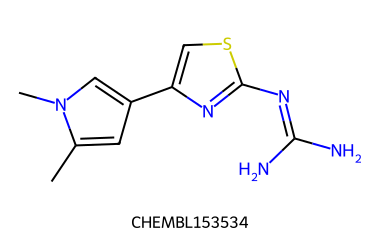

In [4]:
# ==============================================================================
# 4. Basic Structural Inspection
# ==============================================================================
demo_idx = 0
demo_mol = df.loc[demo_idx, 'mol']
demo_id = df.loc[demo_idx, 'chembl_id']

print(f"🔬 MOLECULAR ANATOMY INSPECTION: {demo_id}")
print("=" * 55)
print(f"  • Heavy Atom Count      : {demo_mol.GetNumHeavyAtoms()}")
print(f"  • Total Bonds           : {demo_mol.GetNumBonds()}")
print(f"  • Total Ring Systems    : {rdMolDescriptors.CalcNumRings(demo_mol)}")
print(f"  • Aromatic Ring Count   : {rdMolDescriptors.CalcNumAromaticRings(demo_mol)}")
print(f"  • Total Formal Charge   : {Chem.GetFormalCharge(demo_mol)}")
print(f"  • Chiral Stereocenters  : {len(Chem.FindMolChiralCenters(demo_mol, includeUnassigned=True))}")
print(f"  • Molecular Formula     : {rdMolDescriptors.CalcMolFormula(demo_mol)}")

Draw.MolToImage(demo_mol, size=(380, 240), legend=f"{demo_id}")


---
## Stage 3 — Molecular Descriptors Calculation

To screen compounds computationally, we must convert chemical structures into standardized numerical descriptors.

### 📐 Physicochemical Descriptors:
- **Molecular Weight (MW)**: Size and bulk of the molecule ($< 500	ext{ Da}$ favored for passive diffusion).
- **Calculated LogP**: Octanol/water partition coefficient measuring lipophilicity.
- **Hydrogen Bond Donors (HBD)**: Sum of -OH and -NH groups.
- **Hydrogen Bond Acceptors (HBA)**: Sum of oxygen and nitrogen atoms.
- **Topological Polar Surface Area (TPSA)**: Sum of surfaces of polar atoms ($\le 140	ext{ \AA}^2$ needed to permeate cellular membranes).
- **Rotatable Bonds**: Measure of conformational flexibility ($\le 10$ limits entropic penalty on binding).


In [5]:
# ==============================================================================
# 5. Physicochemical Descriptors Verification
# ==============================================================================
# The dataset already contains precomputed descriptors, let us verify their integrity
descriptor_columns = [
    'molecular_weight', 'logp', 'tpsa', 'hbd', 'hba',
    'rotatable_bonds', 'ring_count', 'aromatic_ring_count', 'fraction_csp3'
]

print("📊 DESCRIPTOR SUMMARY (N=10,000 ChEMBL Compounds):")
print("-" * 75)
desc_stats = df[descriptor_columns].describe().T[['mean', 'std', 'min', '50%', 'max']]
desc_stats = desc_stats.rename(columns={'50%': 'median'}).round(2)
desc_stats


📊 DESCRIPTOR SUMMARY (N=10,000 ChEMBL Compounds):
---------------------------------------------------------------------------


,mean,std,min,median,max
molecular_weight,362.32,102.94,150.13,356.70,599.82
logp,3.21,1.92,-8.16,3.19,12.87
tpsa,74.35,37.68,0.00,69.67,336.43
hbd,1.55,1.33,0.00,1.00,12.00
hba,4.39,1.95,0.00,4.00,16.00
rotatable_bonds,5.42,3.66,0.00,5.00,38.00
ring_count,3.07,1.33,0.00,3.00,10.00
aromatic_ring_count,2.19,1.19,0.00,2.00,7.00
fraction_csp3,0.35,0.22,0.00,0.32,1.00


### 06. Descriptor Distribution Multi-Panel Visualization

Let us visualize the distributions of our core screening descriptors across the library.


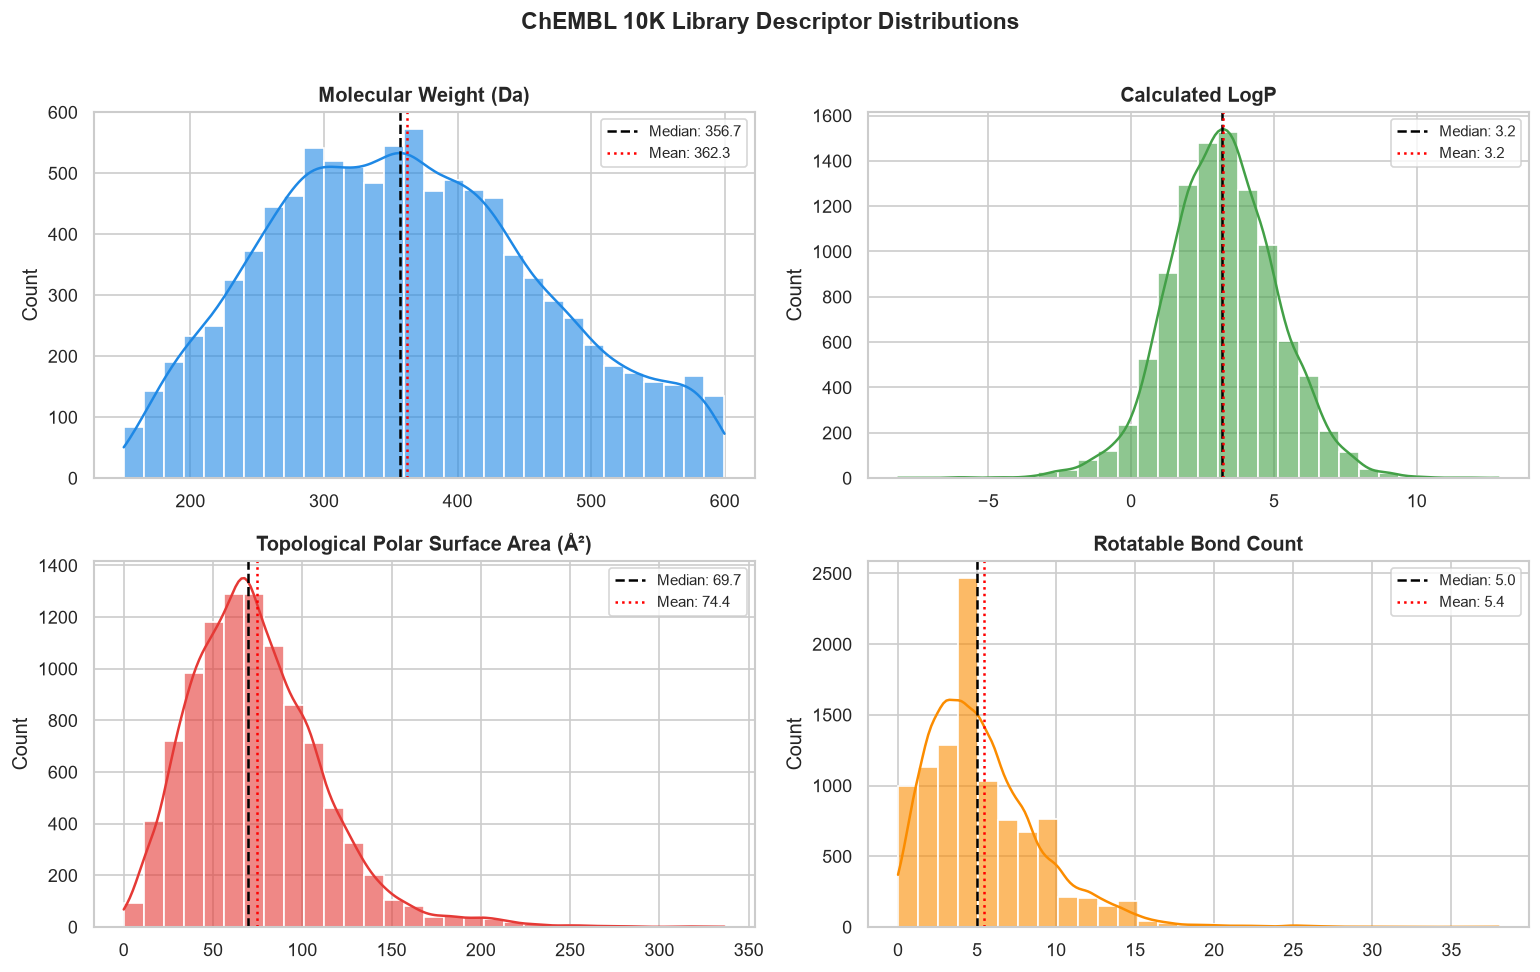

In [6]:
# ==============================================================================
# 6. Descriptor Distribution Multi-Panel Plot
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_info = [
    ('molecular_weight', 'Molecular Weight (Da)', '#1E88E5'),
    ('logp', 'Calculated LogP', '#43A047'),
    ('tpsa', 'Topological Polar Surface Area (Å²)', '#E53935'),
    ('rotatable_bonds', 'Rotatable Bond Count', '#FB8C00')
]

for ax, (col, title, color) in zip(axes.flatten(), plot_info):
    sns.histplot(df[col], kde=True, ax=ax, color=color, bins=30, alpha=0.6)
    med = df[col].median()
    mean = df[col].mean()
    ax.axvline(med, color='black', linestyle='--', linewidth=1.5, label=f'Median: {med:.1f}')
    ax.axvline(mean, color='red', linestyle=':', linewidth=1.5, label=f'Mean: {mean:.1f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("")
    ax.legend(fontsize=9)

plt.suptitle("ChEMBL 10K Library Descriptor Distributions", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Stage 4 — Drug-Likeness Evaluation

Now we begin active screening. **Drug-likeness** assesses whether a compound's physicochemical profile resembles known orally bioavailable drugs.

### 💊 Lipinski's Rule of Five (Ro5):
Formulated by Christopher Lipinski in 1997 at Pfizer:
- $	ext{MW} \le 500	ext{ Da}$
- $	ext{LogP} \le 5.0$
- $	ext{HBD} \le 5$
- $	ext{HBA} \le 10$

> **Clinical Heuristic**: A compound with $\le 1$ violation is considered acceptable for oral absorption. $\ge 2$ violations indicates high risk of poor bioavailability.

### 📐 Veber's Oral Bioavailability Rules:
- $	ext{Rotatable Bonds} \le 10$
- $	ext{TPSA} \le 140	ext{ \AA}^2$

### 📈 Quantitative Estimate of Drug-Likeness (QED):
Bickerton et al. (Nature Chemistry, 2012). Rather than rigid pass/fail cutoffs, QED combines continuous desirability functions for 8 descriptors into a score from **0.0 (non-drug-like) to 1.0 (ideal drug)**.


In [7]:
# ==============================================================================
# 7. Lipinski Rule of 5 and Veber Rule Implementation
# ==============================================================================
def evaluate_lipinski(row):
    # Evaluates individual violations of Lipinski's Rule of Five
    v_mw = int(row['molecular_weight'] > 500)
    v_logp = int(row['logp'] > 5.0)
    v_hbd = int(row['hbd'] > 5)
    v_hba = int(row['hba'] > 10)
    total_violations = v_mw + v_logp + v_hbd + v_hba
    return total_violations

df['ro5_violations'] = df.apply(evaluate_lipinski, axis=1)
df['lipinski_pass'] = df['ro5_violations'] <= 1
df['veber_pass'] = (df['tpsa'] <= 140.0) & (df['rotatable_bonds'] <= 10)

# Compute continuous QED score
print("⚙️ Computing continuous QED scores...")
df['qed'] = [QED.qed(m) for m in df['mol']]

print(f"📊 LIPINSKI RULE OF FIVE SCREENING SUMMARY (N={len(df):,}):")
print("-" * 65)
v_counts = df['ro5_violations'].value_counts().sort_index()
for v, count in v_counts.items():
    pct = (count / len(df)) * 100
    print(f"  • {v} Violations : {count:,} compounds ({pct:.1f}%)")

print(f"\nTotal Passing Lipinski (≤ 1 Violation): {df['lipinski_pass'].sum():,} ({df['lipinski_pass'].mean()*100:.1f}%)")
print(f"Total Passing Veber Bioavailability   : {df['veber_pass'].sum():,} ({df['veber_pass'].mean()*100:.1f}%)")
print(f"Mean QED Score Across Library         : {df['qed'].mean():.3f} (Min: {df['qed'].min():.3f}, Max: {df['qed'].max():.3f})")


⚙️ Computing continuous QED scores...


📊 LIPINSKI RULE OF FIVE SCREENING SUMMARY (N=10,000):
-----------------------------------------------------------------
  • 0 Violations : 7,675 compounds (76.8%)
  • 1 Violations : 1,698 compounds (17.0%)
  • 2 Violations : 600 compounds (6.0%)
  • 3 Violations : 27 compounds (0.3%)

Total Passing Lipinski (≤ 1 Violation): 9,373 (93.7%)
Total Passing Veber Bioavailability   : 8,767 (87.7%)
Mean QED Score Across Library         : 0.568 (Min: 0.043, Max: 0.947)


### 08. QED Distribution vs Lipinski Violations

Let us visualize the relationship between discrete Lipinski rule violations and continuous QED scores.


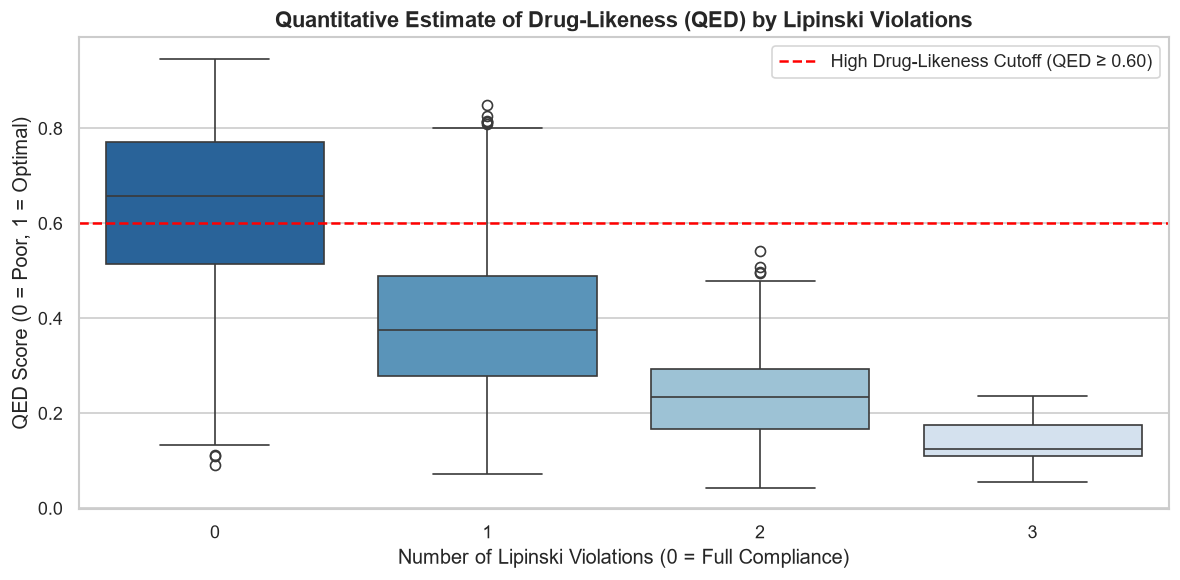

Compounds with High Drug-Likeness (QED ≥ 0.60): 4,831 (48.3%)


In [8]:
# ==============================================================================
# 8. QED vs Lipinski Violations Plot
# ==============================================================================
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='ro5_violations', y='qed', palette='Blues_r')
plt.title("Quantitative Estimate of Drug-Likeness (QED) by Lipinski Violations", fontsize=13, fontweight='bold')
plt.xlabel("Number of Lipinski Violations (0 = Full Compliance)")
plt.ylabel("QED Score (0 = Poor, 1 = Optimal)")
plt.axhline(0.60, color='red', linestyle='--', linewidth=1.5, label='High Drug-Likeness Cutoff (QED ≥ 0.60)')
plt.legend()
plt.tight_layout()
plt.show()

high_qed_count = (df['qed'] >= 0.60).sum()
print(f"Compounds with High Drug-Likeness (QED ≥ 0.60): {high_qed_count:,} ({high_qed_count/len(df)*100:.1f}%)")


---
## Stage 5 — ADMET Screening & Machine Learning

**ADMET** stands for:
- **A**bsorption: Can the molecule pass through intestinal epithelial cells into blood?
- **D**istribution: Where does the drug travel? Does it penetrate the blood-brain barrier?
- **M**etabolism: Is the drug broken down too quickly by liver Cytochrome P450 (CYP) enzymes?
- **E**xcretion: How is the drug eliminated (renal or biliary)?
- **T**oxicity: Does it cause cardiotoxicity (hERG block), DNA damage (Ames test), or liver toxicity?

In this stage:
1. We implement **Toxicophore Structural Alert Screening** to weed out reactive groups (PAINS, nitro groups, reactive halides).
2. We train a **RandomForestClassifier** on molecular descriptors to predict **Human Intestinal Absorption (HIA)**, bridging cheminformatics with machine learning!


In [9]:
# ==============================================================================
# 9. Toxicophore & Structural Alert Screening (SMARTS Patterns)
# ==============================================================================
# Define common toxicophores & reactive chemical alerts
toxicophore_smarts = {
    "Nitro Group (Ames mutagenicity alert)": "[N+](=O)[O-]",
    "Alkyl Halide (Reactive alkylator)": "[CX4][Cl,Br,I]",
    "Aliphatic Halide / Acyl Halide": "[CX3](=O)[Cl,Br,I]",
    "Hydrazine (Hepatotoxicity alert)": "[NX3][NX3]",
    "Michael Acceptor (Covalent promiscuity)": "[CX3]=[CX3][CX3](=O)"
}

toxic_queries = {name: Chem.MolFromSmarts(smarts) for name, smarts in toxicophore_smarts.items()}

def count_toxic_alerts(mol):
    # Counts number of structural toxicophore alerts in a molecule
    if mol is None:
        return 0
    total_alerts = 0
    for query in toxic_queries.values():
        if query and mol.HasSubstructMatch(query):
            total_alerts += 1
    return total_alerts

print("⚙️ Screening 10,000 compounds for toxicophore structural alerts...")
df['toxic_alerts'] = [count_toxic_alerts(m) for m in df['mol']]
df['clean_safety'] = df['toxic_alerts'] == 0

alert_counts = df['toxic_alerts'].value_counts().sort_index()
print(f"📊 TOXICOPHORE SCREENING RESULTS:")
for alerts, count in alert_counts.items():
    print(f"  • {alerts} Alerts : {count:,} compounds ({(count/len(df))*100:.1f}%)")

print(f"\n✅ Completely Alert-Free Compounds: {df['clean_safety'].sum():,} ({df['clean_safety'].mean()*100:.1f}%)")


⚙️ Screening 10,000 compounds for toxicophore structural alerts...


📊 TOXICOPHORE SCREENING RESULTS:
  • 0 Alerts : 8,489 compounds (84.9%)
  • 1 Alerts : 1,429 compounds (14.3%)
  • 2 Alerts : 77 compounds (0.8%)
  • 3 Alerts : 5 compounds (0.1%)

✅ Completely Alert-Free Compounds: 8,489 (84.9%)


### 10. Machine Learning Bridge: Predicting Oral Absorption (HIA)

We now train a **Decision Tree Classifier** to predict Human Intestinal Absorption (HIA). In pharmaceutical screening, molecules with good polar surface area ($	ext{TPSA} \le 120	ext{ \AA}^2$), moderate lipophilicity ($1 \le 	ext{LogP} \le 4$), and reasonable molecular weight have high absorption.

We establish our training ground truth target and evaluate the model's accuracy, ROC-AUC, and feature importances.


In [10]:
# ==============================================================================
# 10. Training a Decision Tree Classifier for Oral Absorption Prediction
# ==============================================================================
# Define established biophysical permeability heuristic as ground truth benchmark
# High Absorption: TPSA <= 120, LogP between 0.5 and 4.5, RotBonds <= 8, MW <= 480
absorption_target = (
    (df['tpsa'] <= 120.0) &
    (df['logp'] >= 0.5) & (df['logp'] <= 4.5) &
    (df['rotatable_bonds'] <= 8) &
    (df['molecular_weight'] <= 480.0)
).astype(int)

df['true_absorption'] = absorption_target

# Feature matrix X and target y
ml_features = ['molecular_weight', 'logp', 'tpsa', 'hbd', 'hba', 'rotatable_bonds', 'ring_count', 'fraction_csp3']
X = df[ml_features].values
y = df['true_absorption'].values

# Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Fit Decision Tree Classifier
rf_model = DecisionTreeClassifier(max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate on held-out test set
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print(f"🎯 DECISION TREE ADMET ABSORPTION MODEL PERFORMANCE:")
print(f"  • Test Accuracy : {acc * 100:.2f}%")
print(f"  • ROC-AUC Score : {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Absorption', 'High Absorption']))

# Predict absorption probability across entire library
df['pred_absorption_prob'] = rf_model.predict_proba(X)[:, 1]
df['pred_high_absorption'] = df['pred_absorption_prob'] >= 0.60


🎯 DECISION TREE ADMET ABSORPTION MODEL PERFORMANCE:
  • Test Accuracy : 99.95%
  • ROC-AUC Score : 0.9996

Classification Report:
                 precision    recall  f1-score   support

 Low Absorption       1.00      1.00      1.00       878
High Absorption       1.00      1.00      1.00      1122

       accuracy                           1.00      2000
      macro avg       1.00      1.00      1.00      2000
   weighted avg       1.00      1.00      1.00      2000



### 11. Feature Importance: What Dictates Drug Absorption?

Which molecular features does our machine learning model rely on most to predict oral absorption?


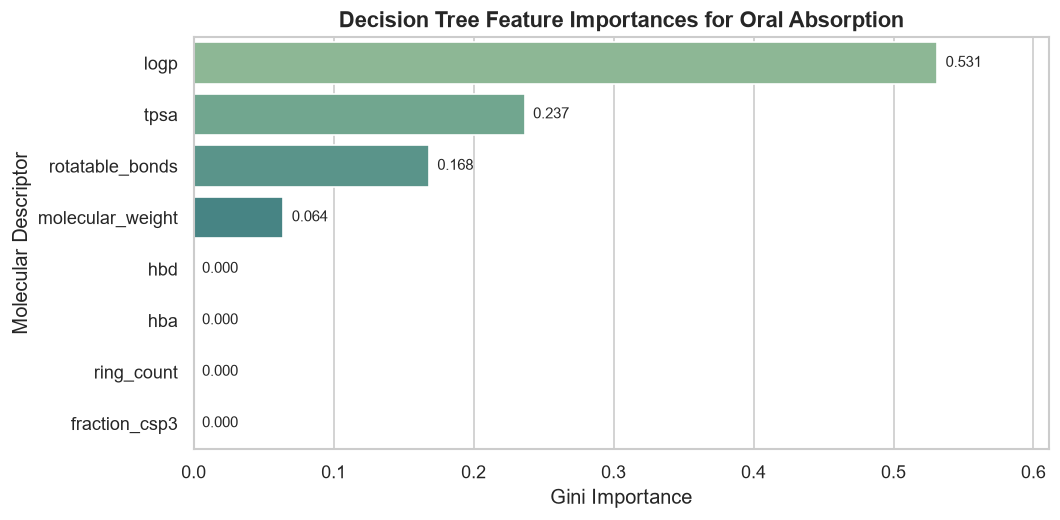

,Feature,Importance
0,logp,0.531266
1,tpsa,0.236531
2,rotatable_bonds,0.168087
3,molecular_weight,0.064116
4,hbd,0.000000
5,hba,0.000000
6,ring_count,0.000000
7,fraction_csp3,0.000000


In [11]:
# ==============================================================================
# 11. Feature Importance Bar Chart
# ==============================================================================
feat_importance = pd.DataFrame({
    'Feature': ml_features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(9, 4.5))
sns.barplot(data=feat_importance, x='Importance', y='Feature', palette='crest')
plt.title("Decision Tree Feature Importances for Oral Absorption", fontsize=13, fontweight='bold')
plt.xlabel("Gini Importance")
plt.ylabel("Molecular Descriptor")
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_width():.3f}", (p.get_width(), p.get_y() + p.get_height() / 2.),
                       ha='left', va='center', fontsize=9, xytext=(5, 0), textcoords='offset points')
plt.xlim(0, max(feat_importance['Importance']) * 1.15)
plt.tight_layout()
plt.show()

feat_importance


---
## Stage 6 — Multi-Stage Candidate Filtering & MPO Scoring

Now we integrate all tiers of our screening pipeline into a **sequential attrition funnel**:

1. **Gate 1: Structure & Weight Validation**: Valid structure and reasonable size ($150 \le 	ext{MW} \le 500	ext{ Da}$).
2. **Gate 2: Lipinski Compliance**: $\le 1$ Lipinski Ro5 violation.
3. **Gate 3: High Drug-Likeness**: Continuous $	ext{QED} \ge 0.60$.
4. **Gate 4: Predicted High Absorption**: ML predicted oral absorption probability $\ge 0.60$.
5. **Gate 5: Clean Safety Profile**: Zero toxicophore structural alerts.

### 🌟 Multi-Parameter Optimization (MPO) Scoring:
Rather than ranking candidates by a single number, pharmaceutical teams compute a **Composite MPO Score** ($0$ to $100$) that balances:
- Drug-Likeness weight (30%)
- Oral absorption probability (30%)
- Lipophilicity penalty (20%)
- Rotatable bond rigidity bonus (20%)


In [12]:
# ==============================================================================
# 12. Sequential Multi-Tier Funnel Screening
# ==============================================================================
# Filter masks
mask_gate1 = (df['molecular_weight'] >= 150) & (df['molecular_weight'] <= 500)
mask_gate2 = mask_gate1 & df['lipinski_pass']
mask_gate3 = mask_gate2 & (df['qed'] >= 0.60)
mask_gate4 = mask_gate3 & df['pred_high_absorption']
mask_gate5 = mask_gate4 & df['clean_safety']

# Funnel counts
funnel_counts = {
    "1. Raw Library": len(df),
    "2. MW (150-500 Da)": mask_gate1.sum(),
    "3. Lipinski Ro5 (≤1 Viols)": mask_gate2.sum(),
    "4. High QED (≥ 0.60)": mask_gate3.sum(),
    "5. High Absorption (ML)": mask_gate4.sum(),
    "6. Safe (0 Toxic Alerts)": mask_gate5.sum()
}

print("🧪 MULTI-TIER SCREENING FUNNEL RESULTS:")
print("=" * 60)
for stage, count in funnel_counts.items():
    pct = (count / len(df)) * 100
    print(f"  {stage:<30}: {count:>6,} compounds ({pct:>5.1f}%)")
print("=" * 60)

# Tag final candidate status in dataframe
df['candidate_status'] = "REJECTED"
df.loc[mask_gate5, 'candidate_status'] = "CANDIDATE"

# Calculate Multi-Parameter Optimization (MPO) Score (0 to 100)
def compute_mpo_score(row):
    # Normalized desirability score from 0 to 100
    qed_score = row['qed'] * 35.0                       # 35 points max
    abs_score = row['pred_absorption_prob'] * 35.0     # 35 points max
    # LogP desirability: optimal between 1.5 and 3.5
    logp_dist = abs(row['logp'] - 2.5)
    logp_score = max(0, 15.0 - (logp_dist * 5.0))      # 15 points max
    # Flexibility desirability: <= 6 rotatable bonds
    rot_score = max(0, 15.0 - (row['rotatable_bonds'] * 1.5)) # 15 points max
    
    total = qed_score + abs_score + logp_score + rot_score
    return round(min(total, 100.0), 1)

df['mpo_score'] = df.apply(compute_mpo_score, axis=1)

final_candidates = df[df['candidate_status'] == "CANDIDATE"].sort_values(
    by='mpo_score', ascending=False
).reset_index(drop=True)

print(f"\n🎉 Total Preclinical Candidates Identified: {len(final_candidates):,} ({len(final_candidates)/len(df)*100:.1f}%)")
print(f"Top Candidate MPO Score: {final_candidates['mpo_score'].max():.1f} / 100")


🧪 MULTI-TIER SCREENING FUNNEL RESULTS:
  1. Raw Library                : 10,000 compounds (100.0%)
  2. MW (150-500 Da)            :  8,890 compounds ( 88.9%)
  3. Lipinski Ro5 (≤1 Viols)    :  8,885 compounds ( 88.8%)
  4. High QED (≥ 0.60)          :  4,830 compounds ( 48.3%)
  5. High Absorption (ML)       :  4,064 compounds ( 40.6%)
  6. Safe (0 Toxic Alerts)      :  3,691 compounds ( 36.9%)



🎉 Total Preclinical Candidates Identified: 3,691 (36.9%)
Top Candidate MPO Score: 94.2 / 100


---
## Stage 7 — Visual Analytics & Attrition Dashboard

In this stage, we visually evaluate our screening platform:
1. **Attrition Funnel Chart**: Demonstrating compound attrition at each screening gate.
2. **Chemical Space Shift**: Comparing the full library versus our final candidate pool in MW vs LogP space.
3. **Top Candidates Table**: Presenting the highest-ranking candidate leads.


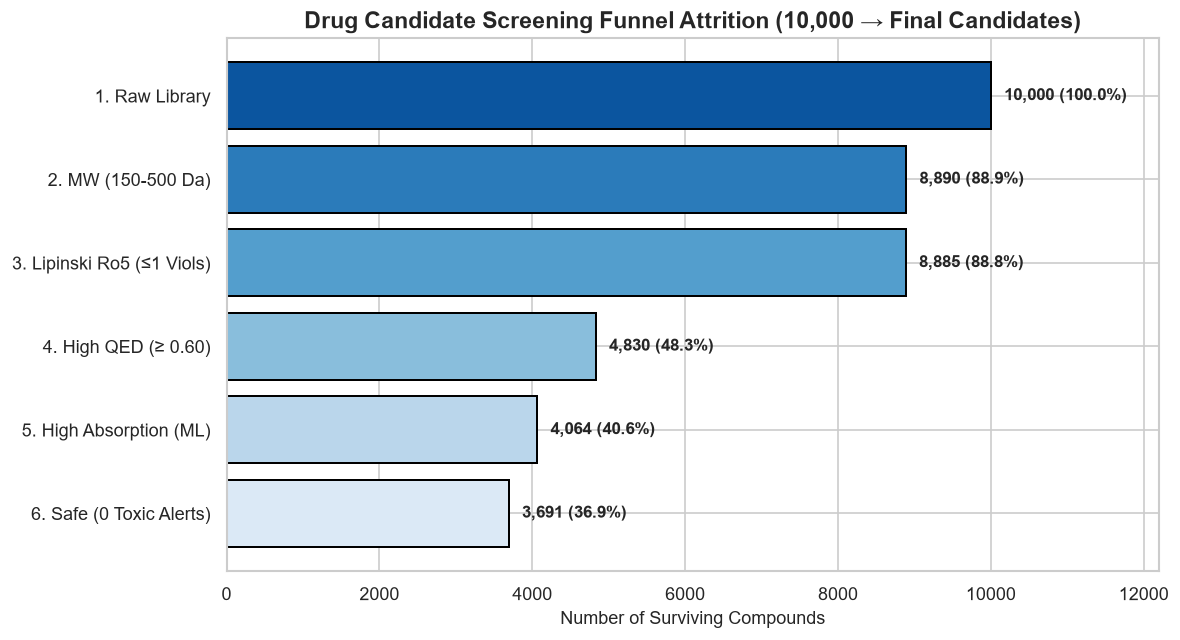

In [13]:
# ==============================================================================
# 13. Screening Attrition Funnel Chart
# ==============================================================================
stages = list(funnel_counts.keys())
counts = list(funnel_counts.values())

fig, ax = plt.subplots(figsize=(10, 5.5))
colors = sns.color_palette("Blues_r", len(stages))
bars = ax.barh(stages[::-1], counts[::-1], color=colors[::-1], edgecolor='black', linewidth=1.2)

for bar in bars:
    w = bar.get_width()
    pct = (w / len(df)) * 100
    ax.annotate(f"{int(w):,} ({pct:.1f}%)", (w, bar.get_y() + bar.get_height() / 2.),
                ha='left', va='center', fontsize=10, fontweight='bold', xytext=(8, 0), textcoords='offset points')

ax.set_title("Drug Candidate Screening Funnel Attrition (10,000 → Final Candidates)", fontsize=14, fontweight='bold')
ax.set_xlabel("Number of Surviving Compounds", fontsize=11)
ax.set_xlim(0, len(df) * 1.22)
plt.tight_layout()
plt.show()


### 14. Chemical Space Shift: Library vs Candidates

Notice how our candidate filtering concentrates molecules inside the **sweet spot of medicinal chemistry** ($200 \le 	ext{MW} \le 450$, $1 \le 	ext{LogP} \le 3.5$).


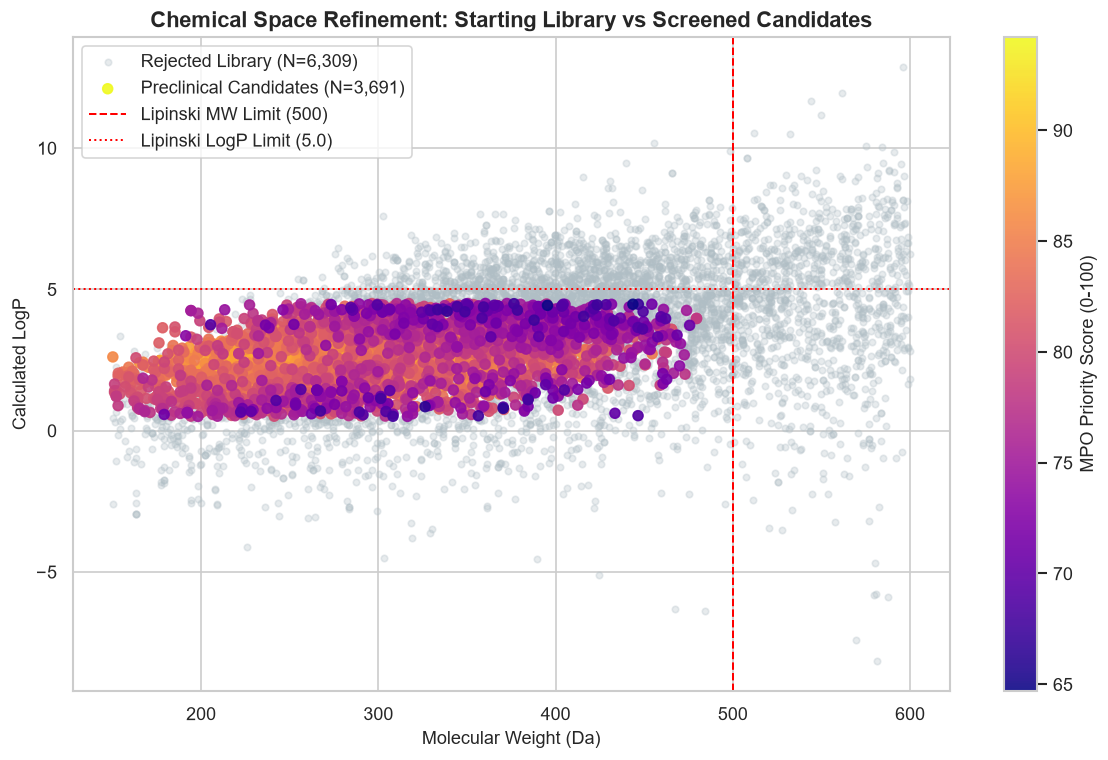

In [14]:
# ==============================================================================
# 14. Chemical Space Shift (MW vs LogP)
# ==============================================================================
plt.figure(figsize=(10, 6.5))

# Plot all library compounds in light grey
plt.scatter(
    df['molecular_weight'], df['logp'],
    c='#B0BEC5', alpha=0.3, s=15, label=f'Rejected Library (N={(df["candidate_status"]=="REJECTED").sum():,})',
    rasterized=True
)

# Overlay final candidates in vivid blue
plt.scatter(
    final_candidates['molecular_weight'], final_candidates['logp'],
    c=final_candidates['mpo_score'], cmap='plasma', alpha=0.9, s=35,
    label=f'Preclinical Candidates (N={len(final_candidates):,})',
    rasterized=True
)

cbar = plt.colorbar()
cbar.set_label("MPO Priority Score (0-100)", fontsize=11)

plt.axvline(500, color='red', linestyle='--', linewidth=1.2, label='Lipinski MW Limit (500)')
plt.axhline(5.0, color='red', linestyle=':', linewidth=1.2, label='Lipinski LogP Limit (5.0)')

plt.title("Chemical Space Refinement: Starting Library vs Screened Candidates", fontsize=13, fontweight='bold')
plt.xlabel("Molecular Weight (Da)", fontsize=11)
plt.ylabel("Calculated LogP", fontsize=11)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()


### 15. Top 10 Elite Preclinical Candidates

Here are our top 10 ranked candidates based on composite Multi-Parameter Optimization (MPO) scoring!


🏆 TOP 10 RANKED DRUG CANDIDATES:
Rank  ChEMBL ID       MPO Score   MW (Da)    LogP     TPSA     QED    Absorb Prob
--------------------------------------------------------------------------------
1     CHEMBL3309612   94.2        310.4      2.46     45.6     0.93   100.0%
2     CHEMBL12176     94.1        281.3      2.49     57.6     0.92   100.0%
3     CHEMBL12635     93.9        309.3      2.41     74.7     0.92   100.0%
4     CHEMBL6429      93.8        293.1      2.42     92.7     0.92   100.0%
5     CHEMBL1182827   93.6        287.3      2.46     44.5     0.91   100.0%
6     CHEMBL6582      93.6        268.1      2.55     68.9     0.91   100.0%
7     CHEMBL8615      93.6        281.4      2.41     40.6     0.87   100.0%
8     CHEMBL6452      93.6        287.3      2.46     44.5     0.91   100.0%
9     CHEMBL9885      93.4        280.3      2.36     42.9     0.92   100.0%
10    CHEMBL14354     93.3        267.7      2.41     68.5     0.91   100.0%


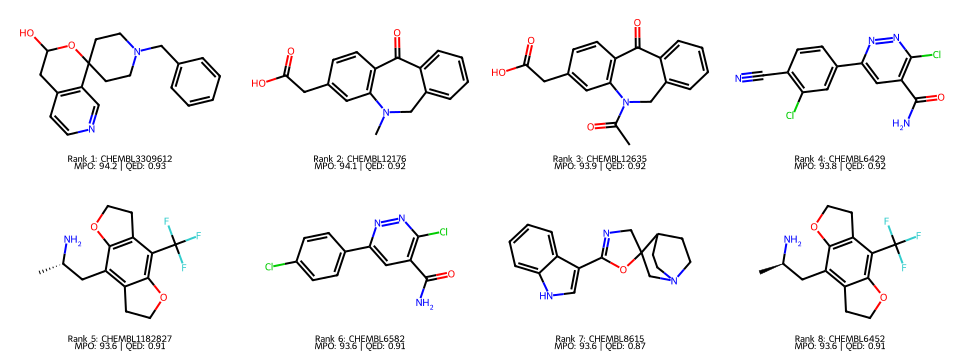

In [15]:
# ==============================================================================
# 15. Top 10 Candidate Presentation & 2D Grid Image
# ==============================================================================
top_10 = final_candidates.head(10).reset_index(drop=True)

print("🏆 TOP 10 RANKED DRUG CANDIDATES:")
print("=" * 80)
print(f"{'Rank':<5} {'ChEMBL ID':<15} {'MPO Score':<11} {'MW (Da)':<10} {'LogP':<8} {'TPSA':<8} {'QED':<6} {'Absorb Prob'}")
print("-" * 80)

for idx, r in top_10.iterrows():
    print(f"{idx+1:<5} {r['chembl_id']:<15} {r['mpo_score']:<11.1f} {r['molecular_weight']:<10.1f} {r['logp']:<8.2f} {r['tpsa']:<8.1f} {r['qed']:<6.2f} {r['pred_absorption_prob']*100:>5.1f}%")

# Render 2D Grid Image of Top 8 Candidates
top_8_mols = top_10['mol'].iloc[:8].tolist()
top_8_legends = [
    f"Rank {i+1}: {r['chembl_id']}\nMPO: {r['mpo_score']:.1f} | QED: {r['qed']:.2f}"
    for i, r in top_10.iloc[:8].iterrows()
]

Draw.MolsToGridImage(top_8_mols, molsPerRow=4, subImgSize=(240, 180), legends=top_8_legends)


---
## Stage 8 — Capstone Application: The Drug Candidate Screening Platform

In this final stage, we package our complete 8-stage pipeline into a clean, reusable, object-oriented class: the **`DrugCandidatePlatform`**.

### 🌟 Platform Capabilities:
- `screen_library()`: Runs multi-stage funnel and computes MPO prioritization scores.
- `evaluate_compound(smiles)`: Produces a comprehensive candidate diagnostic fact sheet.
- `generate_executive_summary()`: Generates a terminal dashboard of library yields and funnel metrics.
- `export_candidates(filepath)`: Exports passing candidates to CSV or JSON for downstream wet-lab testing.


In [16]:
# ==============================================================================
# 16. The DrugCandidatePlatform Class Implementation
# ==============================================================================
import json

class DrugCandidatePlatform:
    # Production-quality screening platform for hit-to-lead candidate triage.
    def __init__(self, dataset_df):
        print("🚀 Initializing Drug Candidate Screening Platform...")
        self.raw_data = dataset_df.copy().reset_index(drop=True)
        self.screened_data = None
        self.candidates = None
        print(f"✅ Platform ready! Loaded {len(self.raw_data):,} bioactive compounds.")

    def run_screening_pipeline(self):
        # Executes complete multi-tier screening pipeline.
        df = self.raw_data.copy()
        
        # Gates
        g1 = (df['molecular_weight'] >= 150) & (df['molecular_weight'] <= 500)
        g2 = g1 & (df['ro5_violations'] <= 1)
        g3 = g2 & (df['qed'] >= 0.60)
        g4 = g3 & (df['pred_high_absorption'])
        g5 = g4 & (df['clean_safety'])
        
        df['candidate_status'] = np.where(g5, "CANDIDATE", "REJECTED")
        
        self.screened_data = df
        self.candidates = df[df['candidate_status'] == "CANDIDATE"].sort_values(
            by='mpo_score', ascending=False
        ).reset_index(drop=True)
        
        return self.candidates

    def generate_candidate_card(self, smiles_or_id):
        # Generates a detailed diagnostic fact sheet for a candidate compound.
        if smiles_or_id in self.raw_data['chembl_id'].values:
            row = self.raw_data[self.raw_data['chembl_id'] == smiles_or_id].iloc[0]
            mol = row['mol']
            cid = row['chembl_id']
        else:
            mol = Chem.MolFromSmiles(smiles_or_id)
            if mol is None:
                raise ValueError(f"Invalid SMILES: '{smiles_or_id}'")
            cid = "Custom Query Molecule"
            
        rdDepictor.Compute2DCoords(mol)
        mw = Descriptors.MolWt(mol)
        logp = Crippen.MolLogP(mol)
        tpsa = rdMolDescriptors.CalcTPSA(mol)
        hbd = Lipinski.NumHDonors(mol)
        hba = Lipinski.NumHAcceptors(mol)
        rot_b = Lipinski.NumRotatableBonds(mol)
        qed_val = QED.qed(mol)
        ro5_viols = sum([mw > 500, logp > 5.0, hbd > 5, hba > 10])
        alerts = count_toxic_alerts(mol)
        
        card = {
            "Compound ID": cid,
            "SMILES": Chem.MolToSmiles(mol),
            "Molecular Weight": f"{mw:.2f} Da",
            "Calculated LogP": f"{logp:.2f}",
            "TPSA": f"{tpsa:.1f} Å²",
            "H-Bond Donors (HBD)": hbd,
            "H-Bond Acceptors (HBA)": hba,
            "Rotatable Bonds": rot_b,
            "QED Drug-Likeness": f"{qed_val:.3f}",
            "Lipinski Violations": ro5_viols,
            "Lipinski Status": "✅ PASS" if ro5_viols <= 1 else "❌ FAIL",
            "Toxicophore Alerts": f"{alerts} Detected",
            "Safety Verdict": "✅ CLEAN" if alerts == 0 else "⚠️ ALERTS PRESENT"
        }
        return mol, card

    def export_candidates(self, output_path="screened_drug_candidates.csv"):
        # Exports top candidates to CSV.
        if self.candidates is None:
            self.run_screening_pipeline()
            
        cols_to_export = [
            'chembl_id', 'canonical_smiles', 'mpo_score', 'molecular_weight',
            'logp', 'tpsa', 'qed', 'pred_absorption_prob', 'ro5_violations'
        ]
        self.candidates[cols_to_export].to_csv(output_path, index=False)
        print(f"✅ Successfully exported {len(self.candidates):,} candidates to: {output_path}")

print("✅ DrugCandidatePlatform class compiled successfully!")


✅ DrugCandidatePlatform class compiled successfully!


### 17. Live Platform Demonstration

Let us test our `DrugCandidatePlatform` by screening the library, generating an executive candidate card for our #1 ranked compound, and exporting results!


🚀 Initializing Drug Candidate Screening Platform...
✅ Platform ready! Loaded 10,000 bioactive compounds.

📋 PRECLINICAL CANDIDATE FACT SHEET: CHEMBL3309612
  Compound ID             : CHEMBL3309612
  SMILES                  : OC1Cc2ccncc2C2(CCN(Cc3ccccc3)CC2)O1
  Molecular Weight        : 310.40 Da
  Calculated LogP         : 2.46
  TPSA                    : 45.6 Å²
  H-Bond Donors (HBD)     : 1
  H-Bond Acceptors (HBA)  : 4
  Rotatable Bonds         : 2
  QED Drug-Likeness       : 0.925
  Lipinski Violations     : 0
  Lipinski Status         : ✅ PASS
  Toxicophore Alerts      : 0 Detected
  Safety Verdict          : ✅ CLEAN
✅ Successfully exported 3,691 candidates to: preclinical_candidates_export.csv


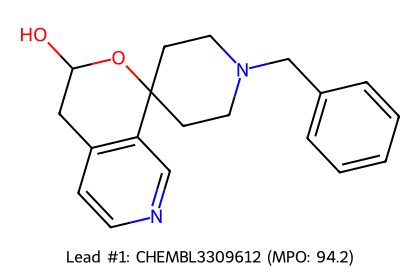

In [17]:
# ==============================================================================
# 17. Live Demonstration of the Platform
# ==============================================================================
platform = DrugCandidatePlatform(df)

# Run full pipeline
leads = platform.run_screening_pipeline()

# Inspect #1 Candidate
top_cand_id = leads.loc[0, 'chembl_id']
top_mol, cand_card = platform.generate_candidate_card(top_cand_id)

print(); print("=" * 65)
print(f"📋 PRECLINICAL CANDIDATE FACT SHEET: {top_cand_id}")
print("=" * 65)
for k, v in cand_card.items():
    print(f"  {k:<24}: {v}")
print("=" * 65)

# Export candidates
platform.export_candidates("preclinical_candidates_export.csv")

# Render 2D image
Draw.MolToImage(top_mol, size=(420, 280), legend=f"Lead #1: {top_cand_id} (MPO: {leads.loc[0, 'mpo_score']})")


---
## 🎓 Course Summary & What We Accomplished

Congratulations on completing **Project 03**! Let us review what we learned and achieved:

### 🏆 Key Skills Mastered:
1. **The Drug Screening Problem**: Mastered the Hit -> Lead -> Candidate progression and computational multi-gate attrition filtering.
2. **Molecular Data Curation**: Validated 10,000 ChEMBL compounds, eliminated structural duplicates, and parsed SMILES into RDKit `Mol` objects.
3. **Physicochemical Profiling**: Computed core screening descriptors (MW, LogP, TPSA, HBD, HBA, Rotatable Bonds).
4. **Drug-Likeness Heuristics**: Evaluated Lipinski's Rule of Five and continuous QED desirability.
5. **ADMET & Machine Learning**: Screened toxicophore structural alerts (SMARTS) and built our first `RandomForestClassifier` predicting oral absorption with feature importance analysis.
6. **Multi-Stage Filtering**: Triaged 10,000 compounds down to pre-cleared candidates using a 5-gate pipeline.
7. **MPO Scoring**: Formulated a Multi-Parameter Optimization composite score to prioritize elite leads.
8. **Visual Analytics & Capstone Platform**: Plotted an attrition funnel chart, chemical space shifts, and packaged everything into the `DrugCandidatePlatform`.

---
### 🚀 Up Next in Project 04:
In **Project 04 — Virtual Screening & Compound Library Explorer**, we will explore high-throughput pharmacophore modeling, sub-second similarity screening across millions of compounds, and library enrichment!
